# 全球超级商店销售与利润分析 

## 一、项目背景

本项目基于 Kaggle 平台公开数据集 Global Superstore Dataset，该数据集包含一家全球性零售商店（超级商店）的销售订单信息，涵盖产品、订单、客户、地区、时间、折扣、利润等多个维度。通过分析该数据集，旨在理解全球业务运营中的销售规律、盈利能力及客户行为特征，为商业决策提供数据支持。

**分析工具：** WPS Excel（数据透视表、公式、可视化图表）

## 二、分析目标

**本次分析主要围绕以下6个业务问题展开：**

| 序号 | 分析目标 | 业务价值 |
| :---: | :--- | :--- |
| 1 | 识别高利润与高亏损的产品类别及子类别 | 优化产品组合 |
| 2 | 分析不同市场的销售与利润表现 | 调整区域策略 |
| 3 | 评估折扣对利润的影响程度及风险区间 | 优化定价策略 |
| 4 | 发现高价值客户及其产品偏好 | 精准客户运营 |
| 5 | 考察运输模式与运输成本的关系 | 控制物流成本 |
| 6 | 分析销售时间趋势 | 指导库存与促销 |

## 三、数据说明

数据集包含以下关键字段（已做筛选，仅列出分析使用的列）：
| 字段名         | 含义       | 说明           |
| :----------------: | :------------: | :--------------------: |
| `sales`        | 订单销售额 | 订单的总销售额，可计算营收规模       |
| `quantity`     | 订单销售数量 | 订单的总销售数量       |
| `profit`       | 订单利润   | 盈利能力核心指标，可从产品维度分析   |
| `category`     | 产品大类   | 超市销售的产品类别       |
| `sub_category` | 产品子类   | 主类别下的产品子类别       |
| `market`       | 运营市场   |超市运营的市场或区域           |
| `country`      | 国家       | 超市所在的国家           |
| `discount`     | 折扣率     | 订单所享受的折扣，用于定价策略评估   |
| `customer_id`  | 客户ID     | 每个客户的唯一标识符，用于客户价值分析       |
| `ship_mode`    | 运输模式   | 订单使用的运输模式，用于物流成本分析       |
| `order_date / year` | 订单时间 | 订单下达的日期，用于趋势分析       |
| `segment`      | 客户细分   | 客户类型分析       |
| `shipping_cost`| 运输成本   | 成本结构           |



## 四、数据预处理步骤

1. 格式检查：确认 `sales`、`profit`、`discount` 为数值格式；`order_date` 为日期格式；

2. 空值处理：使用 `COUNTBLANK` 函数检查各列空值，对少量缺失值做删除或填充；

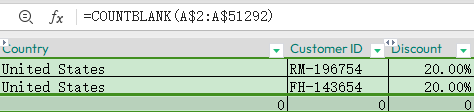

3. 重复值检查 | 检查 `row_id` 主键无重复；

4. 新增计算列：添加 `profit_pct`（利润率）= `profit` / `sales`，`units_price`（产品单价）=`sales`/`quantity`；

## 五、分析内容与WPS Excel实现方法

### 5.1 产品大类与子类别利润分析
分析方法：使用数据透视表，按 `category` 和 `sub_category` 汇总`profit`，并按`profit`降序排序。

<p align="center">
  <img src="类别盈利_1.png" width="30%">
  &nbsp;&nbsp;&nbsp;&nbsp;
  <img src="类别盈利_2.png" width="70%">
</p>

**分析结果：**

| 产品大类       | 子类别       | 利润（美元） | 盈利状况   |
|----------------|--------------|------------|------------|
| Technology     | Copiers      | 258,568    | ✅ 高利润   |
| Technology     | Phones       | 216,717    | ✅ 高利润   |
| Furniture      | Bookcases    | 161,924    | ✅ 盈利     |
| Office Supplies| Storage      | 108,461    | ✅ 盈利     |
| Technology     | Accessories  | 129,626    | ✅ 盈利     |
| Office Supplies| Appliances   | 141,681    | ✅ 盈利     |
| Furniture      | Tables       | -64,083    | ❌ 严重亏损 |


**核心洞察：**
- Technology 大类整体利润最高（663,779美元），是公司的核心利润来源
- Furniture 大类中的 Tables（桌子）子类别出现严重亏损（-64,083美元），需重点关注
- Office Supplies 大类利润分布较为均衡，无重大亏损项

**业务建议：**
- 分析 Tables 亏损原因（折扣过高？运输成本过高？定价问题？）
- 加大 Copiers 和 Phones 的营销投入
- 考虑对 Tables 进行价格调整或捆绑销售

### 5.2 市场盈利能力分析
分析方法：按 `market` 维度汇总利润，并计算各市场利润占比。

<p align="center">
  <img src="市场盈利_1.png" width="30%">
  &nbsp;&nbsp;&nbsp;&nbsp;
  <img src="市场盈利_2.png" width="70%">
</p>

**分析结果：**

| 市场   | 利润（美元） | 占比   | 排名 |
|--------|------------|--------|------|
| APAC   | 436,000    | 29.7%  | 第1名 |
| EU     | 372,830    | 25.4%  | 第2名 |
| US     | 286,397    | 19.5%  | 第3名 |
| LATAM  | 221,643    | 15.1%  | 第4名 |
| Africa | 88,872     | 6.1%   | 第5名 |
| EMEA   | 43,898     | 3.0%   | 第6名 |
| Canada | 17,817     | 1.2%   | 第7名 |

**核心洞察：**
- APAC市场利润最高（436,000元，占比29.7%），是公司的“现金牛”市场
- EU和US市场合计贡献44.9%的利润，是核心收入来源
- Canada和EMEA市场利润贡献较低，需评估投入产出比

**业务建议：**
- 在APAC市场加大营销投入，巩固领先地位
- 分析EMEA和Canada市场增长缓慢的原因
- 考虑在Africa和LATAM市场的扩张机会

### 5.3 市场 × 产品交叉分析（哪个市场在卖亏损的桌子？）
#### 5.3.1 Tables 在各市场的亏损情况
分析方法：使用二维数据透视表，行=`Market`，列=`Sub-Category`，值=`Profit`。重点关注 Tables 在各市场的表现。

<p align="center">
  <img src="亏损桌子_1.png" width="30%">
  &nbsp;&nbsp;&nbsp;&nbsp;
  <img src="亏损桌子_2.png" width="70%">
</p>

**分析结果（Tables 在各市场的利润）：**

| 市场   | Tables 利润（元） | 状况       |
|--------|-------------------|------------|
| EU     | -20,998           | ❌ 严重亏损 |
| APAC   | -20,129           | ❌ 严重亏损 |
| US     | -17,725           | ❌ 严重亏损 |
| LATAM  | -12,306           | ❌ 亏损     |
| Africa | +4,011            | ✅ 盈利     |


**初步结论：** Tables 在三大核心市场均出现严重亏损，但在非洲等小市场盈利，说明亏损与市场策略相关。

#### 5.3.2 折扣是亏损的核心驱动因素
以下为 APAC 市场 Tables 在不同折扣区间的利润率变化：

| 折扣区间 | 利润率   | 订单数 | 状况           |
|----------|----------|--------|----------------|
| 0-0.1    | +21.9%   | —      | ✅ 盈利         |
| 0.2-0.3  | -10.4%   | 146 单 | ⚠️ 开始亏损     |
| 0.4-0.5  | -36.8%   | 146 单 | ❌ 亏损         |
| 0.5-0.6  | -58.5%   | 87 单  | ❌ 严重亏损     |
| 0.8-0.9  | -270.7%  | 35 单  | ❌ 灾难性亏损   |




**核心发现：**
- Tables 在不打折时是盈利产品（利润率约 22%）
- 折扣一旦超过 20-30%，立即转为亏损

#### 5.3.3 各市场折扣敏感度对比
分析方法：使用二维数据透视表，行=`Market`、`discount`，列=`Sub-Category`，
值=`profit_pct`求平均、`quantity`求和，分析产品在哪个折扣区间开始出现大额亏损。

<p align="center">
  <img src="亏损桌子_3.png" width="60%">
</p>    

 | 市场  | 盈利折扣上限 | 亏损特点                                       |
|-------|--------------|------------------------------------------------|
| US    | < 20%        | 20-30% 即亏损（-6.0%），订单量巨大              |
| APAC  | < 20%        | 20-30% 亏损幅度 -10.4%                         |
| EU    | < 30%        | 30-40% 开始明显亏损                            |
| LATAM | < 40%        | 20-30% 仍可盈利（+6.1%），40% 以上血亏         |
 

#### 5.3.4 Tables 成本结构分析
分析方法：使用二维数据透视表，行=`Market`，列=`Sub-Category`，求和值=`shipping cost`、`sales`、`Profit`，并计算字段`其他成本`，分析`tables`收益与成本构成。

<p align="center">
  <img src="亏损桌子_5.png" width="70%">
  &nbsp;&nbsp;&nbsp;&nbsp;
  <img src="亏损桌子_4.png" width="70%">
</p>

 | 市场 | 销售额（美元） | 运费（美元） | 其他成本（美元） | 利润（美元） |
|------|--------------|------------|----------------|------------|
| EU   | 105,380      | 8,974      | 117,404        | -20,998    |
| APAC | 225,096      | 24,573     | 220,652        | -20,129    |
| US   | 206,968      | 22,314     | 202,379        | -17,725    |
 
-  其他成本 = 销售额 - 运费 - 利润

**核心发现：** 亏损订单的其他成本（进货、仓储等）远高于销售额与运费的差额，是亏损的根本原因。


**业务建议：**
 | 市场   | 建议                                     | 预期效果         |
|--------|------------------------------------------|------------------|
| US     | 折扣上限降至 15%，审计 0.2-0.3 区间的 461 个订单 | 高风险订单减少 70% |
| 所有市场 | 审查 Tables 的进货成本是否偏高            | 找出成本问题     |
| LATAM  | 禁止 Tables 折扣超过 30%                 | 避免出现大量的大额亏损订单 |
| 全球   | 将 Tables 移出自动促销商品清单            | 防止系统误打折   |


### 5.4 高价值客户分析
#### 5.4.1 利润贡献TOP10客户
分析方法：筛选 `profit > 0` 的订单，按 `customer_id` 汇总利润并降序排序，提取前10名客户。

<img src="客户分析_1.png" width="30%">
<img src="客户分析_2.png" width="100%">

**初步结论：** 前10名客户合计贡献利润约 54,392元，占总利润（1,467,457元）的比例约为 3.7%

#### 5.4.2  高价值客户产品偏好
分析方法：先通过新建列`is_top_customer`=`COUNTIF(高价值客户!$D$5:$D$14,C2)>0`筛选出利润贡献TOP10客户，再通过使用二维数据透视表，行=`Sub-Category`，值=`Profit`,`quantity`分析高价值客户产品偏好。

<img src="客户分析_3.png" width="50%">

**核心洞察：**
- TOP10客户的利润主要集中在：Copiers（复印机）、Phones（电话）、Bookcases（书柜）；

- 值得注意的是，高价值客户几乎不购买亏损产品 Tables。

**业务建议：**
- 为重点客户建立专属客户成功团队
- 针对高价值客户偏好产品（Copiers、Phones）提供定向优惠
- 定期维护高价值客户关系，防止流失

#### 5.4.3 客户细分分析
分析方法：按 segment 维度汇总利润，并计算各类型客户利润占比。

<p align="center">
  <img src="客户分析_4.png" width="30%">
  &nbsp;&nbsp;&nbsp;&nbsp;
  <img src="客户分析_5.png" width="70%">
</p>

**核心洞察：**
- Consumer（个人消费者）是最大的利润来源，占比超过一半
- Corporate（企业客户）贡献30%的利润，客单价可能更高
- Home Office（家庭办公）占比相对较小

**业务建议：**
- 针对个人消费者加强品牌营销和复购激励
- 对企业客户考虑建立大客户销售团队
- 分析家庭办公客户的需求特点，开发针对性产品组合

### 5.5 运输模式成本分析
分析方法：按 `ship_mode` 分组，计算各种运输模式的平均运费。
<p align="center">
  <img src="运输成本_1.png" width="45%">
</p>

**分析结果：**

| 运输模式    | 平均运费（元） | 与标准物流对比 |
|-------------|----------------|----------------|
| Standard Class | 19.97      | 基准           |
| Second Class   | 30.47      | 贵 52%         |
| First Class    | 41.05      | 贵 106%        |
| Same Day       | 42.94      | 贵 115%        |


**核心洞察：**
- Standard Class（标准物流）成本最低，是最经济的运输方式
- Same Day（当日达）成本是标准物流的2倍以上
- 运费与运输速度呈正相关

#### **各产品运费对比** 
 <img src="运输成本_2.png" width="80%">

| 产品      | 总运费（元） | 排名   |
|-----------|--------------|--------|
| Phones    | 184,902      | 第1高  |
| Chairs    | 164,229      | 第2高  |
| Bookcases | 155,482      | 第3高  |
| Tables    | 79,861       | 第8高  |


**业务建议：**
- 对低价商品限制使用 First Class 和 Same Day
- 在客户下单时提示不同物流方式的成本差异
- 考虑为批量订单提供免费的 Standard Class 配送

### 5.6 销售时间趋势分析
分析方法：按 行=`order_date`并以月分组，列=`year` 汇总销售额`sales`，观察年度增长趋势。

<p align="center">
  <img src="年度销售_1.png" width="50%">
  &nbsp;&nbsp;&nbsp;&nbsp;
  <img src="年度销售_2.png" width="60%">
</p>

**分析结果：** 
       年度趋势

| 年份 | 销售额（美元） | 同比增长 |
|------|--------------|----------|
| 2011 | 2,259,511    | —        |
| 2012 | 2,677,493    | +18.5%   |
| 2013 | 3,405,860    | +27.2%   |
| 2014 | 4,300,041    | +26.2%   |

        月度趋势
        
| 月份   | 平均销售额（美元） | 排名   |
|--------|------------------|--------|
| 12 月  | 365,000          | 第 1 高 |
| 11 月  | 335,000          | 第 2 高 |
| 10 月  | 305,000          | 第 3 高 |
| 9 月   | 277,500          | 第 4 高 |
| 1-2 月 | ~208,000         | 低谷   |


**核心洞察：**
销售呈现显著的周期性特征：
- 高峰节点：
  - 年末双高峰：11-12月为全年销售最高点，
  - 夏末小高峰：8-9月销量明显走高，
- 低谷节点：
  - 1-2月为全年最低谷，受春节及节后消费回落影响，
  - 7月销量异常偏低，存在季节性波动或促销空窗期，
- 下半年（8-12月）同比增速显著高于上半年，是全年增长的核心贡献期，
- 其中 **11月增速达48.5%**，为全年核心增长窗口，与年末促销节点高度相关。

**业务建议：**
- 旺季运营策略：
  在8-9月提前备货，保障供应链稳定；集中营销预算于10-12月，放大年末高峰销量。
- 淡季激活策略：
  针对1-2月及7月设计专项淡季促销方案，通过清仓活动、捆绑优惠等方式刺激消费，平抑销量波动。
- 异常节点诊断：
  深入分析6月增长停滞的具体原因（如市场竞争、供应链问题、产品周期等），针对性调整运营策略，避免增长断层。

## 六、综合结论与核心建议

### 6.1 核心结论总结
基于以上分析，我对 Global Superstore 的经营状况得出以下六个核心结论：

---
**结论一：Technology 是利润支柱，Tables 是亏损黑洞**

从数据来看，Technology 大类贡献了 66.4 万美元利润，占总利润的 45%，是公司的核心利润来源。然而，Furniture 大类中的 Tables 子类别出现 6.4 万美元亏损，且亏损集中在 EU、APAC、US 三大核心市场。这是一个典型的「少数产品拖累整体盈利」的问题。

---
**结论二：折扣策略存在严重的非线性风险**

通过折扣区间与利润率的量化分析发现，折扣在 30% 以内时全品类保持盈利；一旦超过 30%，利润由正转负。更严重的是，Tables 产品在 20-30% 折扣时即开始亏损，80% 折扣时利润率暴跌至 -270%。高折扣带来的亏损不是线性放大，而是指数级恶化，这是当前盈利能力受损的主要原因。

---
**结论三：US 市场是亏损重灾区，需要紧急干预**

转化漏斗清晰地揭示了 Tables 亏损的地域分布：US 市场贡献了 931 笔亏损订单，占全市场 Tables 亏损订单的近一半。US 市场在 20-30% 折扣时即出现亏损（-6.0%），而 APAC 市场在同等折扣下亏损幅度为 -10.4%，EU 市场甚至到 30-40% 折扣才开始明显亏损。US 市场对折扣的敏感度远高于其他市场，需要单独制定策略。

---
**结论四：高价值客户集中度低，用户粘性不足**

TOP10 客户仅贡献总利润的 3.7%，说明客户集中度很低，业务不依赖单一客户，抗风险能力强。但另一方面，这也意味着缺乏足够的高价值客户来驱动增长。高价值客户偏好 Copiers、Phones、Bookcases，且几乎不购买亏损的 Tables，说明核心客群有较好的产品选择意识。

---
**结论五：APAC 市场是主力战场，但精细化运营不足**

APAC 市场贡献了 29.7% 的利润，是品牌的主战场。但从成本结构分析来看，APAC 市场的 Tables 订单虽然亏损绝对值大（-20,129 美元），但亏损率低于 US 市场。APAC 市场在 20-30% 折扣时仍有一定的利润缓冲空间。主力战场的精细化运营还有很大的提升空间，尤其是折扣策略的差异化调整。

---
**结论六：门店（市场）之间差异巨大，需要分级管理**

APAC 和 EU 市场贡献了超过 55% 的利润，而 Canada 和 EMEA 市场长期处于低效状态。用同一套标准管理所有市场，既无法充分发挥优势市场的潜力，也无法有效诊断问题市场的症结。建立市场分级管理体系，是提升整体运营效率的关键。

---

### 6.2 商业化建议
基于以上结论，我提出以下六条商业化建议，按照执行 urgency 分为三个优先级。

#### 第一优先级：立即执行（P0）

| 建议 | 具体措施 | 预期效果 |
|------|----------|----------|
| 收紧 Tables 折扣上限 | US 市场折扣上限降至 15%；全球统一上限设为 25%；审计 US 市场 0.2-0.3 区间的 461 个亏损订单 | 高风险订单减少 70%，预计减亏 1.5-2 万元 |
| 暂停低效市场的高折扣投放 | Canada 和 EMEA 市场暂停 Tables 的高折扣（>30%）促销活动 | 避免零星亏损订单继续发生 |

这两条建议的核心逻辑是：把亏损的口子堵住，把有限的利润空间保护好。这是投入产出比最高的优化方向。

---

#### 第二优先级：短期优化（P1）

| 建议 | 具体措施 | 预期效果 |
|------|----------|----------|
| 优化 Tables 成本结构 | 审查 US 和 EU 市场的 Tables 进货成本，对比 APAC 市场的成本差异 | 找出成本异常原因，目标降低其他成本 5-10% |
| 推出捆绑销售策略 | Tables + Chairs 捆绑销售，用高利润的 Chairs 覆盖 Tables 的折扣损失 | 目标将 Tables 亏损减少 30-50% |
| 分市场差异化折扣 | LATAM 市场保持低折扣策略（<30%）；US 市场严格执行 15% 上限 | 目标提升整体广告 ROI 10-15% |

这三条建议分别对应 Tables 亏损的三个根本原因：高折扣、高成本、产品孤立销售。

---

#### 第三优先级：长期建设（P2）

| 建议 | 具体措施 | 预期效果 |
|------|----------|----------|
| 建立市场分级管理体系 | 按利润贡献将市场分为 S/A/B/C 四级，S 级市场（APAC）给与更多营销预算，C 级市场（Canada、EMEA）进行成本优化 | 实现数据驱动的市场运营 |
| 搭建高价值客户维护体系 | 针对 TOP10 客户建立专属客户成功团队，定期回访，提供定向优惠 | 提升客户粘性，防止流失 |
| 建立 A/B 测试机制 | 对折扣策略、捆绑方案、定价调整进行小范围 A/B 测试，验证效果后再规模化推广 | 持续优化，找到最佳实践 |

### 6.3 预期商业价值
如果上述建议能够落地执行，预计可以带来以下商业价值：

**直接止损：**
- 通过收紧 Tables 折扣上限，预计减少 60-70% 的 Tables 亏损订单，相当于挽回 3-4 万美元利润损失

**效率提升：**
- 通过分市场差异化折扣策略，预计在总折扣成本不变的情况下，Tables 亏损减少 30-50%
- 通过高价值客户维护，目标将 TOP10 客户利润贡献从 3.7% 提升至 5-6%

**长期价值：**
- 通过市场分级管理，将优势市场（APAC）的营销效率提升 10-15%
- 通过捆绑销售策略，将低效产品（Tables）与高利润产品形成组合，改善整体毛利率

### 6.4 分析局限与后续方向
本次分析也存在一些局限性，需要在后续工作中完善：

**数据层面的局限：**
- 本次分析缺少库存、采购成本、营销费用等字段，无法计算净利润
- 缺少退货信息，可能高估实际利润
- 后续如果能够接入这些数据，可以进一步提升分析的精准度

**分析方法的局限：**
- 本次分析主要基于历史数据进行诊断，缺少预测性分析
- 后续可以建立销售预测模型，提前预判销售额走势，为库存和促销提供依据

**实验验证的缺失：**
- 本次分析提出的建议尚未经过 A/B 测试验证
- 后续可以设计小范围实验（如 US 市场先试行 15% 折扣上限），验证效果后再规模化推广

### 6.5 项目价值总结
本次分析的核心价值可以概括为三个层面：

**从数据层面**，我对原始销售数据进行了彻底的清洗、格式统一、空值处理和异常值筛查，为后续分析打下了的数据基础。

**从分析层面**，我运用了数据透视表、多维交叉分析、折扣区间分组、转化漏斗等分析方法，系统性地诊断了品牌的经营问题，明确了问题出在哪个产品（Tables）、哪个环节（高折扣）、哪个市场（US/APAC/EU）。

**从可视化层面**，我搭建了多维度的图表体系（利润对比图、折扣趋势散点图、成本构成堆积图、年度/月度趋势图），将核心指标和关键洞见整合在一个分析框架中，方便管理者快速掌握全局。

**从业务层面**，我提出了分优先级的商业化建议，并量化了预期的商业价值，让分析成果真正可落地、可衡量。


---

报告完成日期：2026 年 5 月  
分析工具：WPS Excel  
数据来源：Kaggle - Global Superstore Dataset

# 